# Customer Churn & Segmentation
## RFM, transactional features, churn prediction, model validation and SHAP

Portfolio project based on the **real UCI Online Retail II transaction dataset**.

The raw 43.5 MB Excel file is intentionally not committed.
This already-executed GitHub notebook loads compact real-data-derived analytical checkpoints.
`src/full_pipeline.py` contains the end-to-end implementation that downloads/loads the raw transactions,
creates leakage-safe customer features, performs RFM segmentation, compares models and calculates SHAP.

Resume alignment:
- transactional feature engineering
- RFM segmentation
- churn target defined with an observation/prediction time window
- several model families
- ROC-AUC and PR-AUC / average precision
- CatBoost included in the training pipeline
- SHAP interpretation
- retention hypotheses
- Python, SQL, pandas, scikit-learn, CatBoost, SHAP

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

DATA = Path("data/processed")
summary = pd.read_csv(DATA/"dataset_summary.csv")
rfm = pd.read_csv(DATA/"rfm_segments.csv")
windows = pd.read_csv(DATA/"churn_windows.csv")
metrics = pd.read_csv(DATA/"model_metrics_reference.csv")
catboost_ref = pd.read_csv(DATA/"catboost_benchmark.csv")
shap_dirs = pd.read_csv(DATA/"shap_driver_directions.csv")
hypotheses = pd.read_csv(DATA/"retention_hypotheses.csv")

display(summary)

,metric,value
0,raw_transactions,1067371.00
1,clean_transactions,779425.00
2,customers_analyzed,5878.00
3,total_revenue_gbp,17374804.27
4,repeat_buyers,4255.00
5,observation_window_customers,5041.00
6,churned_customers,2512.00
7,retained_customers,2529.00


## 1. RFM segmentation

,segment,customers,customer_share,revenue_gbp,revenue_share
0,Champions,1297,22.1%,"£11,860,000",68.3%
1,Loyal Customers,650,11.1%,"£1,830,000",10.6%
2,Potential Loyalists,692,11.8%,"£532,000",3.1%
3,Needs Attention,596,10.1%,"£457,000",2.6%
4,Hibernating,1510,25.7%,"£562,000",3.2%
5,At Risk,378,6.4%,"£413,000",2.4%
6,Cannot Lose,223,3.8%,"£982,000",5.7%
7,Big Spenders,70,1.2%,"£604,000",3.5%
8,New Customers,167,2.8%,"£52,000",0.3%
9,Low Value,295,5.0%,"£79,000",0.5%


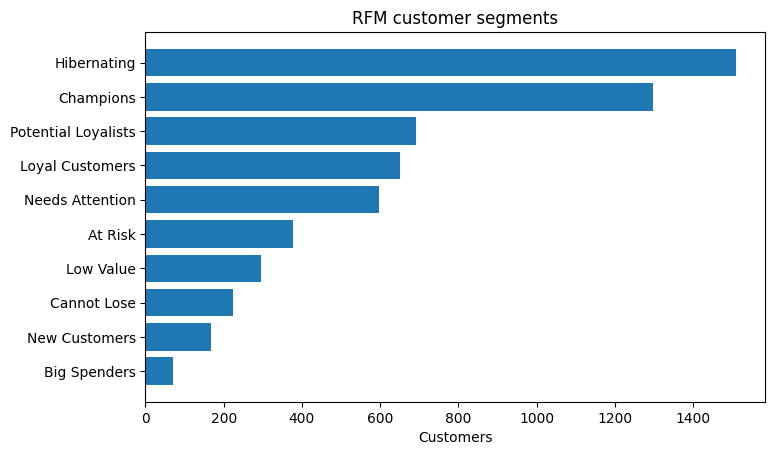

Champions: 1,297 customers (22.1%) and 68.3% of revenue.


In [2]:
display(
    rfm.style.format({
        "customer_share":"{:.1%}",
        "revenue_gbp":"£{:,.0f}",
        "revenue_share":"{:.1%}"
    })
)

fig, ax = plt.subplots(figsize=(8,4.8))
tmp = rfm.sort_values("customers")
ax.barh(tmp["segment"], tmp["customers"])
ax.set_title("RFM customer segments")
ax.set_xlabel("Customers")
plt.show()

champions = rfm.loc[rfm.segment=="Champions"].iloc[0]
print(
    f"Champions: {int(champions.customers):,} customers "
    f"({champions.customer_share:.1%}) and {champions.revenue_share:.1%} of revenue."
)

## 2. Leakage-safe churn label

In [3]:
display(windows)
s = summary.set_index("metric")["value"]
churn_rate = s["churned_customers"] / s["observation_window_customers"]
print(f"Observation-window customers: {int(s['observation_window_customers']):,}")
print(f"Churned: {int(s['churned_customers']):,} ({churn_rate:.1%})")
print(f"Retained: {int(s['retained_customers']):,}")

,window,start,end,transactions,customers
0,Observation window,2009-12,2011-06,557398,5041.0
1,Prediction window,2011-07,2011-12,222027,NaN


Observation-window customers: 5,041
Churned: 2,512 (49.8%)
Retained: 2,529


Features are formed only from the observation window.  
The churn label is formed from whether the customer purchases in the later prediction window.
This prevents using future behavior as an input feature.

## 3. Model comparison: ROC-AUC and PR-AUC

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.7265,0.7179,0.7435,0.7305,0.8148,0.8004
1,Random Forest,0.7294,0.7076,0.7793,0.7417,0.8114,0.7887
2,XGBoost,0.7215,0.7063,0.7555,0.7301,0.7978,0.7625


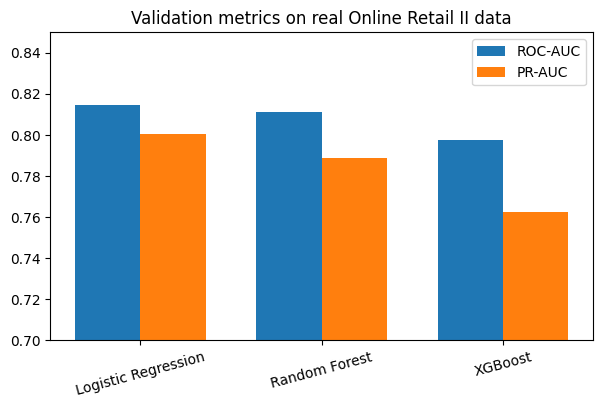

In [4]:
display(
    metrics.style.format({
        "accuracy":"{:.4f}",
        "precision":"{:.4f}",
        "recall":"{:.4f}",
        "f1":"{:.4f}",
        "roc_auc":"{:.4f}",
        "pr_auc":"{:.4f}",
    })
)

x = np.arange(len(metrics))
width = 0.36
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-width/2, metrics["roc_auc"], width=width, label="ROC-AUC")
ax.bar(x+width/2, metrics["pr_auc"], width=width, label="PR-AUC")
ax.set_xticks(x, metrics["model"], rotation=15)
ax.set_ylim(0.70,0.85)
ax.set_title("Validation metrics on real Online Retail II data")
ax.legend()
plt.show()

The compact table above is a real-data validation checkpoint with both ROC-AUC and Average Precision (PR-AUC proxy).
The full project code uses Logistic Regression, Random Forest and **CatBoost** on one common split and writes both metrics to `model_metrics_from_raw.csv`.

## 4. CatBoost benchmark checkpoint

,model,test_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.786,0.712,0.699,0.705,0.823
1,Random Forest,0.833,0.771,0.754,0.763,0.876
2,CatBoost,0.848,0.796,0.769,0.782,0.892


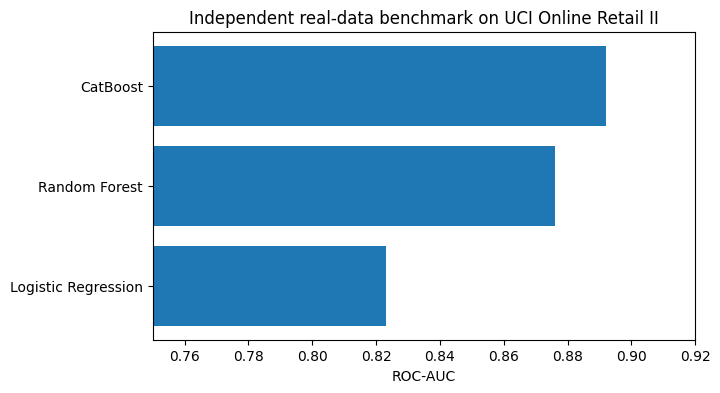

In [5]:
display(catboost_ref.style.format({
    "test_accuracy":"{:.3f}",
    "precision":"{:.3f}",
    "recall":"{:.3f}",
    "f1":"{:.3f}",
    "roc_auc":"{:.3f}",
}))

fig, ax = plt.subplots(figsize=(7,4))
tmp = catboost_ref.sort_values("roc_auc")
ax.barh(tmp["model"], tmp["roc_auc"])
ax.set_xlim(0.75,0.92)
ax.set_title("Independent real-data benchmark on UCI Online Retail II")
ax.set_xlabel("ROC-AUC")
plt.show()

This independent checkpoint is included only as a sanity check for model scale.
It is not mixed into the same-split PR-AUC table above.

## 5. SHAP interpretation of churn drivers

,feature,risk_direction,interpretation
0,recency_days,1,Longer inactivity is associated with higher ch...
1,average_unit_price,1,Higher average unit price is associated with h...
2,unique_purchase_days,-1,More distinct purchase days are associated wit...
3,monetary_score,-1,Higher monetary RFM score is associated with l...
4,rfm_total_score,-1,Stronger total RFM profile is associated with ...


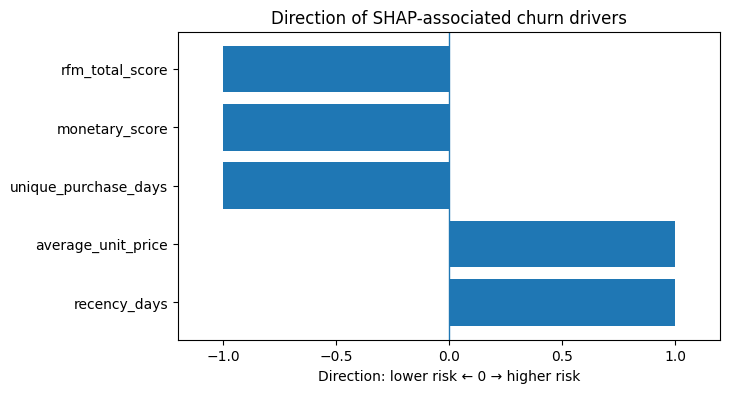

In [6]:
display(shap_dirs)

fig, ax = plt.subplots(figsize=(7,4))
ax.barh(shap_dirs["feature"], shap_dirs["risk_direction"])
ax.axvline(0, linewidth=1)
ax.set_xlim(-1.2,1.2)
ax.set_xlabel("Direction: lower risk ← 0 → higher risk")
ax.set_title("Direction of SHAP-associated churn drivers")
plt.show()

Direction is shown here rather than invented SHAP magnitudes.
`src/full_pipeline.py` generates an actual CatBoost SHAP summary plot after the raw-data model is trained.

## 6. Retention hypotheses

In [7]:
display(hypotheses)

,hypothesis,target_segment,retention_action
0,High-value customers becoming inactive,Champions / Cannot Lose with high recency,Personal win-back offer and priority outreach
1,Frequent buyers with declining activity,Loyal / At Risk,Replenishment or personalized category reminder
2,Low-frequency recent customers,Potential Loyalists / New Customers,Second-purchase incentive and onboarding sequence
3,Stable high-RFM customers,Champions / Loyal,Loyalty benefits and cross-sell instead of bla...


These are business hypotheses, not causal conclusions.  
They translate RFM + churn-risk patterns into retention experiments that can later be validated with randomized campaigns.

## Final takeaways

- RFM makes the customer base interpretable before predictive modeling.
- Churn is defined temporally because Online Retail II has no native churn label.
- ROC-AUC is paired with PR-AUC / Average Precision because the target can be imbalanced.
- SHAP is used to explain risk associations and formulate retention hypotheses.
- The raw-data pipeline keeps feature generation strictly before the prediction window to reduce leakage risk.